<a href="https://colab.research.google.com/github/sizhky/Modern-Computer-Vision-with-PyTorch/blob/master/Chapter11/simple_auto_encoder_with_different_latent_size.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# %pip install -q torch_snippets
from torch_snippets import *
from torch_snippets.torch_loader import Report

import torch
import torch.nn as nn
from torch.utils.data import random_split, Dataset, DataLoader
import matplotlib.pyplot as plt

from torchvision.datasets import MNIST
from torchvision import transforms
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.Lambda(lambda x: x.to(device))
])

In [3]:
trn_ds = MNIST('../data/MNIST', transform=img_transform, train=True, download=True)
val_ds = MNIST('../data/MNIST', transform=img_transform, train=False, download=True)

In [4]:
batch_size = 256
trn_dl = DataLoader(trn_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

In [5]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latend_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128), nn.ReLU(True),
            nn.Linear(128, 64), nn.ReLU(True), 
            #nn.Linear(64, 12),  nn.ReLU(True), 
            nn.Linear(64, latent_dim))
        self.decoder = nn.Sequential(
            #nn.Linear(latent_dim, 12), nn.ReLU(True),
            nn.Linear(latent_dim, 64), nn.ReLU(True),
            nn.Linear(64, 128), nn.ReLU(True), 
            nn.Linear(128, 28 * 28), nn.Tanh())

    def forward(self, x):
        x = x.view(len(x), -1)
        x = self.encoder(x)
        x = self.decoder(x)
        x = x.view(len(x), 1, 28, 28)
        return x
        

In [6]:
# %pip install torch_summary
from torchsummary import summary
model = AutoEncoder(3).to(device)
summary(model, torch.zeros(2,1,28,28));

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 3]                   --
|    └─Linear: 2-1                       [-1, 128]                 100,480
|    └─ReLU: 2-2                         [-1, 128]                 --
|    └─Linear: 2-3                       [-1, 64]                  8,256
|    └─ReLU: 2-4                         [-1, 64]                  --
|    └─Linear: 2-5                       [-1, 3]                   195
├─Sequential: 1-2                        [-1, 784]                 --
|    └─Linear: 2-6                       [-1, 64]                  256
|    └─ReLU: 2-7                         [-1, 64]                  --
|    └─Linear: 2-8                       [-1, 128]                 8,320
|    └─ReLU: 2-9                         [-1, 128]                 --
|    └─Linear: 2-10                      [-1, 784]                 101,136
|    └─Tanh: 2-11                        [-1, 784]                 

In [7]:
def train_batch(input, model, criterion, optimizer):
    model.train()
    optimizer.zero_grad()
    output = model(input)
    loss = criterion(output, input)
    loss.backward()
    optimizer.step()
    return loss

@torch.no_grad()
def validate_batch(input, model, criterion):
    model.eval()
    output = model(input)
    loss = criterion(output, input)
    return loss

EPOCH: 1.000  val_loss: 0.193  trn_loss: 0.252  (18.56s - 74.26s remaining)
EPOCH: 2.000  val_loss: 0.173  trn_loss: 0.182  (36.95s - 55.43s remaining)
EPOCH: 3.000  val_loss: 0.164  trn_loss: 0.169  (55.42s - 36.95s remaining)
EPOCH: 4.000  val_loss: 0.156  trn_loss: 0.160  (73.95s - 18.49s remaining)
EPOCH: 5.000  val_loss: 0.151  trn_loss: 0.154  (92.31s - 0.00s remaining)


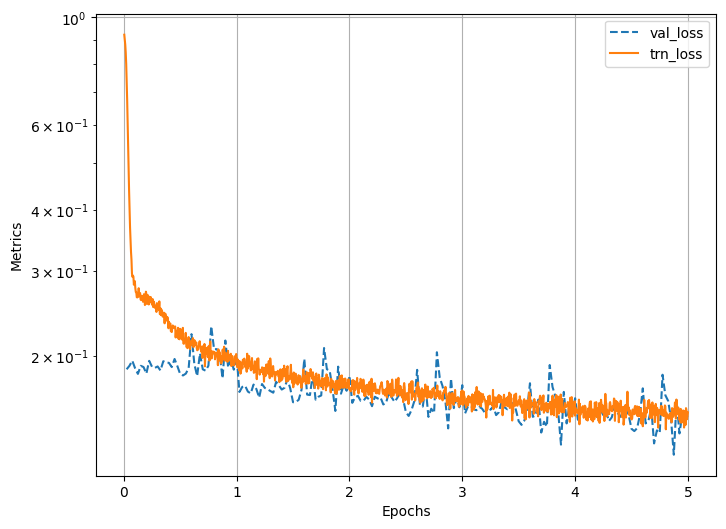

In [8]:
model = AutoEncoder(3).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

num_epochs = 5
log = Report(num_epochs)

for epoch in range(num_epochs):
    N = len(trn_dl)
    for ix, (data, _) in enumerate(trn_dl):
        loss = train_batch(data, model, criterion, optimizer)
        log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r')

    N = len(val_dl)
    for ix, (data, _) in enumerate(val_dl):
        loss = validate_batch(data, model, criterion)
        log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')
    log.report_avgs(epoch+1)
log.plot(log=True)

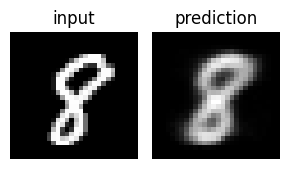

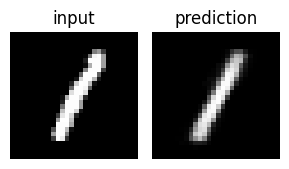

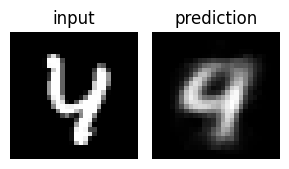

In [9]:
for _ in range(3):
    ix = np.random.randint(len(val_ds))
    im, _ = val_ds[ix]
    _im = model(im[None])[0]
    fig, ax = plt.subplots(1,2,figsize=(3,3)) 
    show(im[0], ax=ax[0], title='input')
    show(_im[0], ax=ax[1], title='prediction')
    plt.tight_layout()
    plt.show()

EPOCH: 1.000  val_loss: 0.133  trn_loss: 0.231  (18.58s - 74.32s remaining)
EPOCH: 2.000  val_loss: 0.099  trn_loss: 0.114  (37.52s - 56.28s remaining)
EPOCH: 3.000  val_loss: 0.081  trn_loss: 0.091  (56.18s - 37.45s remaining)
EPOCH: 4.000  val_loss: 0.073  trn_loss: 0.079  (74.80s - 18.70s remaining)
EPOCH: 5.000  val_loss: 0.067  trn_loss: 0.072  (93.45s - 0.00s remaining)


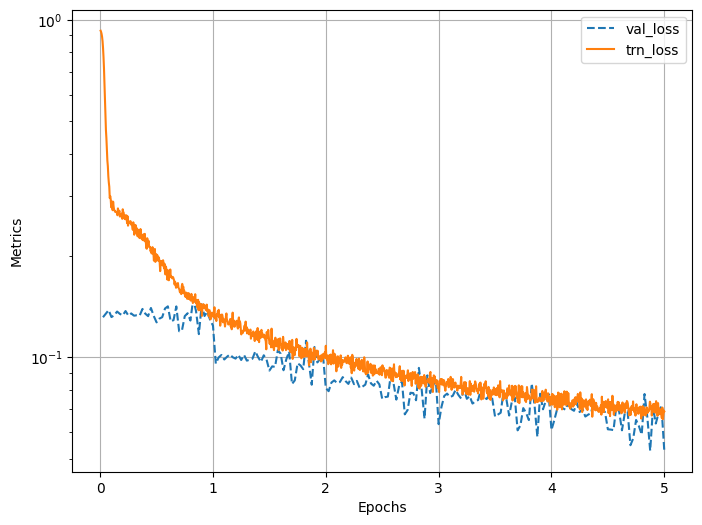

EPOCH: 1.000  val_loss: 0.208  trn_loss: 0.260  (18.68s - 74.73s remaining)
EPOCH: 2.000  val_loss: 0.189  trn_loss: 0.198  (37.29s - 55.94s remaining)
EPOCH: 3.000  val_loss: 0.181  trn_loss: 0.185  (56.00s - 37.33s remaining)
EPOCH: 4.000  val_loss: 0.175  trn_loss: 0.177  (74.65s - 18.66s remaining)
EPOCH: 5.000  val_loss: 0.170  trn_loss: 0.173  (93.64s - 0.00s remaining)


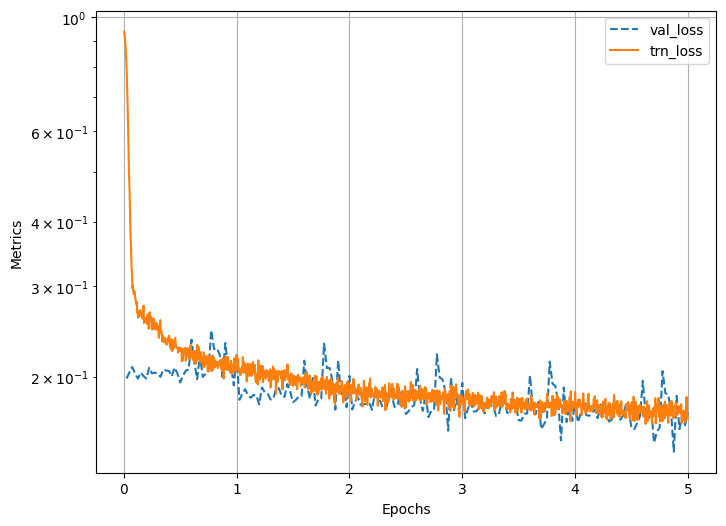

EPOCH: 1.000  val_loss: 0.187  trn_loss: 0.253  (19.22s - 76.86s remaining)
EPOCH: 2.000  val_loss: 0.162  trn_loss: 0.172  (38.37s - 57.56s remaining)
EPOCH: 3.000  val_loss: 0.154  trn_loss: 0.158  (57.54s - 38.36s remaining)
EPOCH: 4.000  val_loss: 0.149  trn_loss: 0.152  (76.75s - 19.19s remaining)
EPOCH: 5.000  val_loss: 0.146  trn_loss: 0.148  (95.97s - 0.00s remaining)


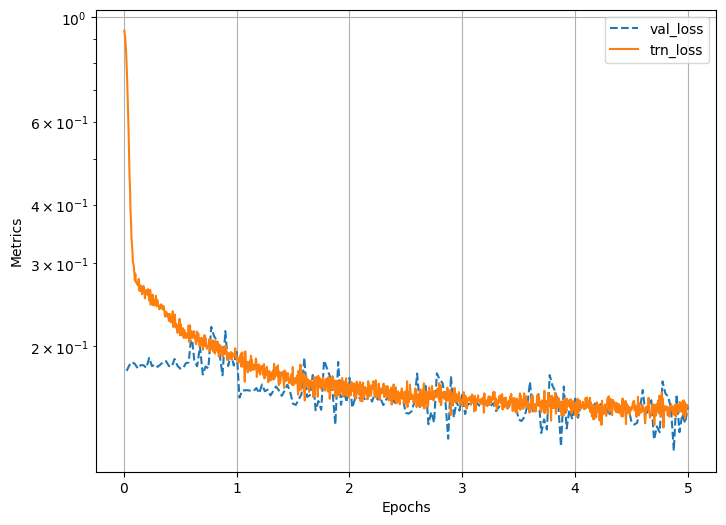

EPOCH: 1.000  val_loss: 0.180  trn_loss: 0.260  (19.18s - 76.72s remaining)
EPOCH: 2.000  val_loss: 0.142  trn_loss: 0.156  (38.39s - 57.59s remaining)
EPOCH: 3.000  val_loss: 0.130  trn_loss: 0.136  (57.60s - 38.40s remaining)
EPOCH: 4.000  val_loss: 0.125  trn_loss: 0.128  (76.79s - 19.20s remaining)
EPOCH: 5.000  val_loss: 0.121  trn_loss: 0.124  (95.96s - 0.00s remaining)


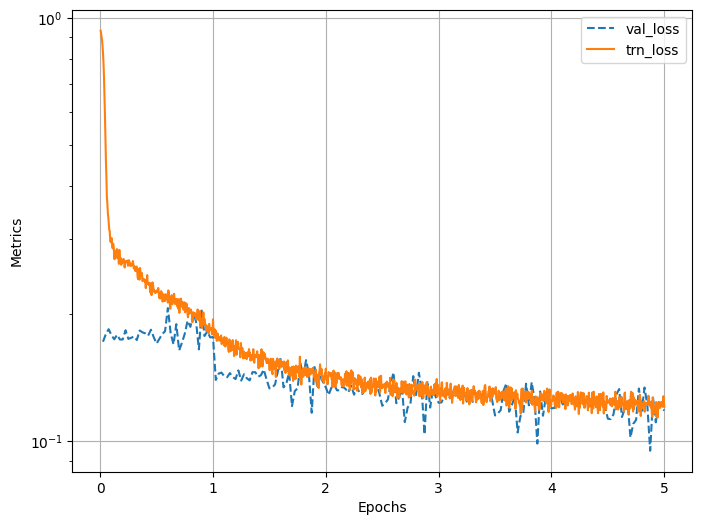

EPOCH: 1.000  val_loss: 0.144  trn_loss: 0.250  (19.14s - 76.57s remaining)
EPOCH: 2.000  val_loss: 0.110  trn_loss: 0.125  (38.32s - 57.48s remaining)
EPOCH: 3.000  val_loss: 0.099  trn_loss: 0.105  (57.32s - 38.21s remaining)
EPOCH: 4.000  val_loss: 0.094  trn_loss: 0.098  (75.86s - 18.96s remaining)
EPOCH: 5.000  val_loss: 0.091  trn_loss: 0.094  (94.45s - 0.00s remaining)


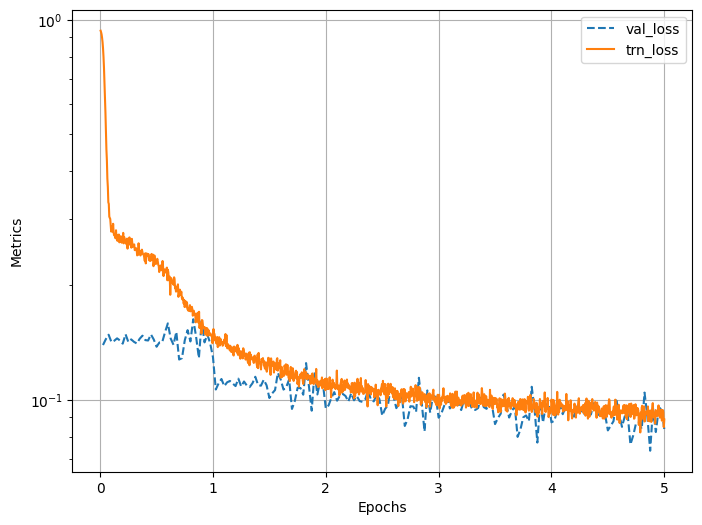

In [10]:
def train_aec(latent_dim):
    model = AutoEncoder(latent_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

    num_epochs = 5
    log = Report(num_epochs)

    for epoch in range(num_epochs):
        N = len(trn_dl)
        for ix, (data, _) in enumerate(trn_dl):
            loss = train_batch(data, model, criterion, optimizer)
            log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r')

        N = len(val_dl)
        for ix, (data, _) in enumerate(val_dl):
            loss = validate_batch(data, model, criterion)
            log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')
        log.report_avgs(epoch+1)
    log.plot(log=True)
    return model

aecs = [train_aec(dim) for dim in [50, 2, 3, 5, 10]]

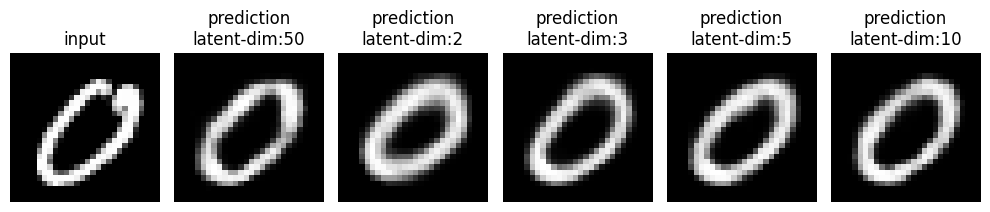

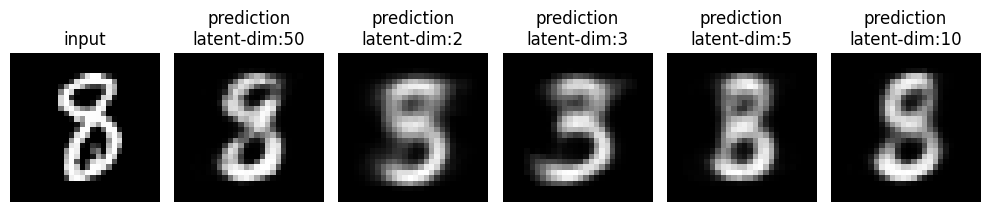

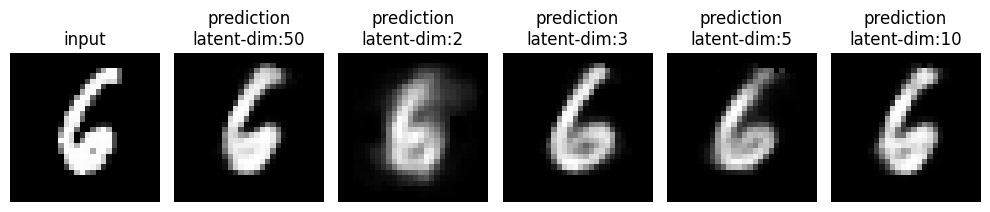

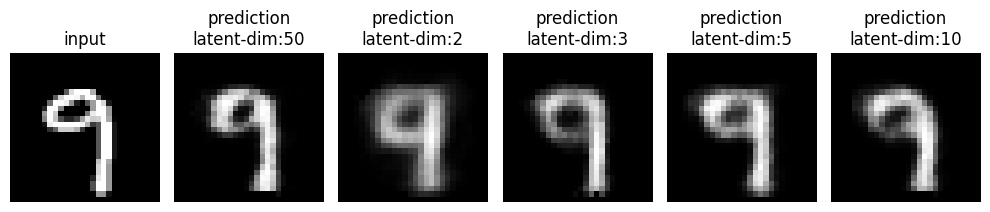

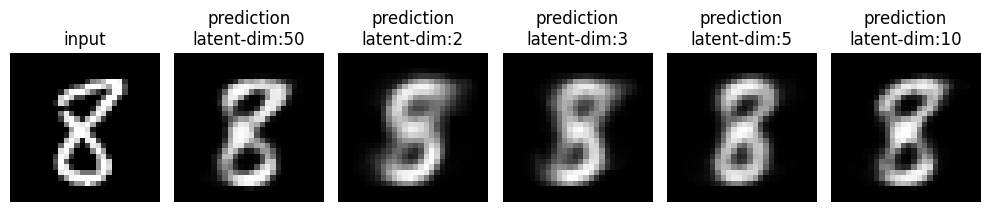

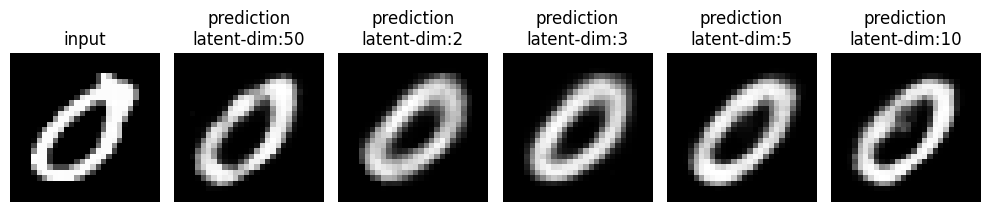

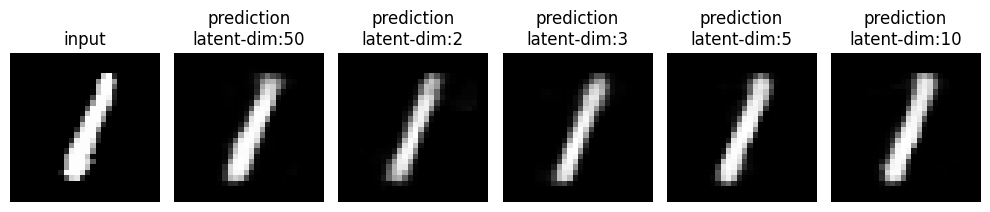

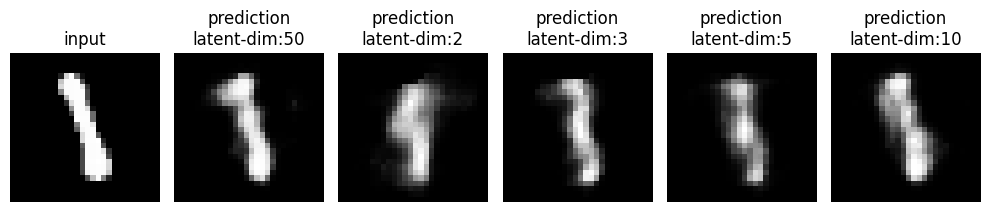

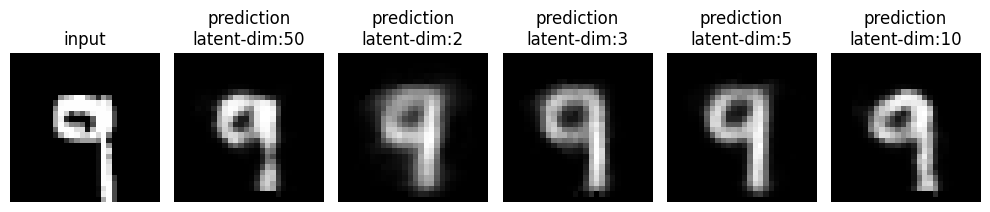

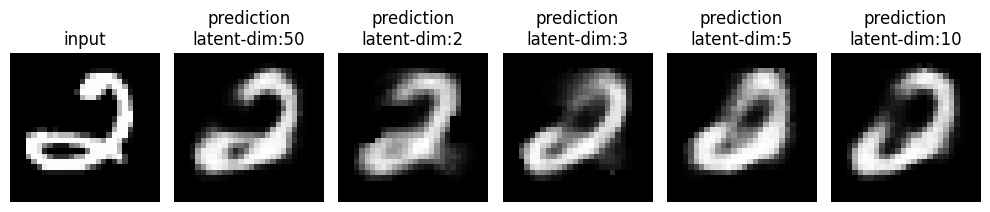

In [12]:
for _ in range(10):
    ix = np.random.randint(len(val_ds))
    im, _ = val_ds[ix]
    fig, ax = plt.subplots(1, len(aecs)+1, figsize=(10,4))
    ax = iter(ax.flat)
    show(im[0], ax=next(ax), title='input')
    for model in aecs:
        _im = model(im[None])[0]
        show(_im[0], ax=next(ax), title=f'prediction\nlatent-dim:{model.latend_dim}')
    plt.tight_layout()
    plt.show()